# RESNET-20 for classification of the CIFAR-10 Dataset

- **See my original try for the svhn dataset: [here](https://github.com/skrithick/SVHN_with_resnet_18/)**

- Initially under the guidance of my mentor Rishabh, I began learning resnets with SVHN and got 90+ accuracy in 2 epochs. Issue was svhn is just numbers, and cifar10 has got more complex objects. So when I  didn't get good accuracy I kinda got demotivated. Hence, I made it my goal to get 90+ accuracy with cifar10, resnet18 in under 15 epochs.

- Throughout this project I tried my best to make everyhing as simple as possible, so I kept rewriting my code until I got the least no. of lines but could still read it.

- My main goal however was to understand the workings of resnet and compare different resnet architectures and understand why some worked better than others

- **( I've attached my initial testing with the svhn dataset above )**

- This model uses a resnet-18 architecture with an initial 3x3 conv instead of 7x7 + maxpool as I don't need to resize the images, they're already 32x32.

- I used the AdamW optimizer as I read that it implements weight decay more efficiently.

- I also used a learning rate scheduler, to produce better results with less epochs, as I strictly wanted to test the different results in **15 epochs**.

- The scheduler I used was OneCycle as:
  - AdamW needs smaller initial learning rates
  - And it produced the best results for small no. of epochs

In [12]:
import torch
import torchvision
import torch.nn.functional as F
import numpy as np
import copy
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import pyplot as plt
from torch import nn, optim
from torchvision import transforms
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import classification_report, confusion_matrix
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## Below I've defined the Residual Block and the actual neural net.

My original code had a tonof loops and lines to make this work. I've tried hard to simplify it using python tricks I learnt recently

In [13]:
class conv(nn.Module):
  def __init__(self, inp, out, stride):
    super().__init__()

    self.base = nn.Sequential(
      nn.Conv2d(inp, out, kernel_size=3, stride=stride, padding=1, bias=False),
      nn.BatchNorm2d(out),
      nn.ReLU(),
      nn.Conv2d(out, out, kernel_size=3, stride=1, padding=1, bias=False),
      nn.BatchNorm2d(out)
    )

    self.identity = nn.Sequential(
        nn.Conv2d(inp, out, kernel_size=1, stride=stride, bias=False),
        nn.BatchNorm2d(out)
    ) if (stride != 1 or inp != out) else nn.Identity()

  def forward(self, x):
    return F.relu(self.base(x) + self.identity(x))

Again, I had some sort of addiction to make it in the least number of lines as possible as compared to my other implementations so my code might be messy, sorry in advance

In [14]:
architecture = [64]*2 + [128]*2 + [256]*2 + [512]*2

class ImageMan(nn.Module):
  def __init__(self):
    super().__init__()

    prev_channel = architecture[0]
    res_layers = []

    for channel in architecture:
        stride = 1 if (prev_channel == channel) else 2
        block = conv(prev_channel, channel, stride)
        res_layers.append(block)
        prev_channel = channel
        

    self.model = nn.Sequential(
        # this is to match the channel count and input size
        nn.Conv2d(3, architecture[0], kernel_size=3, stride=1, padding=1, bias=False),
        nn.BatchNorm2d(architecture[0]),
        nn.ReLU(),
        # recently learned about the splat operator, probably the coolest name for any operator in python
        *res_layers,
        nn.AdaptiveAvgPool2d((1, 1)),
        nn.Flatten(),
        nn.Linear(architecture[-1], 10)
    )

  def forward(self, x):
    return self.model(x)

In [15]:
# I got the mean and std values from the dataset source.
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])
# I've learnt that this kind of transform helps prevent memorization
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

full_train_dataset = torchvision.datasets.CIFAR10('/kaggle/input/datasets/pankrzysiu/cifar10-python', train=True, download=False, transform=transform)
test_dataset = torchvision.datasets.CIFAR10('/kaggle/input/datasets/pankrzysiu/cifar10-python', train=False, download=False, transform=transform)

train_size = int(0.85 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

train_subset, val_subset = random_split(full_train_dataset, [train_size, val_size])
train_subset = copy.deepcopy(train_subset) # so that changing the transform on the train subset won't affect the val one
train_subset.dataset.transform = train_transform

train_loader = DataLoader(train_subset, 64, shuffle=True, num_workers=2)
val_loader = DataLoader(val_subset, 64, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, 64, shuffle=False, num_workers=2)

In [16]:
model = nn.DataParallel(ImageMan()).to(device)
epochs = 20
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01)
scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=0.01,
    epochs=epochs,
    steps_per_epoch=len(train_loader)
)
criterion = nn.CrossEntropyLoss()

Future Me Here: Later on when working with the transformer and lstm, I used cleaner code, keeping the training code in a contained function

Again, I had some kind of obsession with using python tricks and whatnot to make my code small.

In [17]:
tracking = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
raw = {'raw_train': [], 'raw_val': []}
least_loss = float('inf')

for e in range(epochs):
  [tracking[k].append(0.0) for k in tracking]

  model.train()
  for X, y in train_loader:
    X, y = X.to(device), y.to(device)

    optimizer.zero_grad()
    y_ = model(X)
    loss = criterion(y_, y)
    loss.backward()
    optimizer.step()
    scheduler.step()
    correct = (y_.argmax(1) == y).sum().item()
    raw['raw_train'].append(loss.item())
    tracking['train_loss'][-1] += loss.item() / len(train_loader)
    tracking['train_acc'][-1] += correct * 100 / len(train_loader.dataset)

  model.eval()
  with torch.inference_mode():
    for X, y in val_loader:

      X, y = X.to(device), y.to(device)
      y_ = model(X)
      val_loss = criterion(y_, y)
      correct = (y_.argmax(1) == y).sum().item()
      raw ['raw_val'].append(val_loss.item())
      tracking['val_loss'][-1] += val_loss.item() / len(val_loader)
      tracking['val_acc'][-1] += correct * 100 / len(val_loader.dataset)

  if val_loss < least_loss:
      least_loss = val_loss
      torch.save(model.state_dict(), 'cifarman.pt')

  print(f'{e+1})', end=' ')
  for k in tracking:
      print(f'{k}: {tracking[k][-1]:.2f}', end=' | ')
  print()

1) train_loss: 1.48 | train_acc: 45.70 | val_loss: 1.52 | val_acc: 50.36 | 
2) train_loss: 1.09 | train_acc: 61.52 | val_loss: 1.37 | val_acc: 56.51 | 
3) train_loss: 0.93 | train_acc: 67.47 | val_loss: 1.03 | val_acc: 65.00 | 
4) train_loss: 0.82 | train_acc: 71.85 | val_loss: 0.90 | val_acc: 70.31 | 
5) train_loss: 0.73 | train_acc: 74.84 | val_loss: 0.89 | val_acc: 71.19 | 
6) train_loss: 0.66 | train_acc: 77.13 | val_loss: 1.29 | val_acc: 63.64 | 
7) train_loss: 0.60 | train_acc: 79.26 | val_loss: 0.66 | val_acc: 78.43 | 
8) train_loss: 0.55 | train_acc: 81.09 | val_loss: 0.69 | val_acc: 77.69 | 
9) train_loss: 0.52 | train_acc: 82.33 | val_loss: 0.84 | val_acc: 75.23 | 
10) train_loss: 0.48 | train_acc: 83.70 | val_loss: 0.58 | val_acc: 80.56 | 
11) train_loss: 0.44 | train_acc: 85.05 | val_loss: 0.44 | val_acc: 85.39 | 
12) train_loss: 0.39 | train_acc: 86.71 | val_loss: 0.45 | val_acc: 85.03 | 
13) train_loss: 0.35 | train_acc: 87.79 | val_loss: 0.44 | val_acc: 85.76 | 
14) trai

In [18]:
model.load_state_dict(torch.load('cifarman.pt', weights_only=True))

<All keys matched successfully>

In [19]:
test_loss, test_acc = 0.0, 0.0
preds = []
actuals = []

model.eval()
with torch.inference_mode():
  for X, y in test_loader:

    X, y = X.to(device), y.to(device)
    y_ = model(X)
    
    loss = criterion(y_, y)
    pred = y_.argmax(1)
    correct = (pred == y).sum().item()

    test_loss += loss.item() / len(test_loader)
    test_acc += correct / len(test_loader.dataset)

    preds.extend(pred.cpu().numpy())
    actuals.extend(y.cpu().numpy())

print(f"Final Test Loss: {test_loss:.4f} | Final Test Acc: {test_acc:.2%}")

Final Test Loss: 0.3729 | Final Test Acc: 87.91%


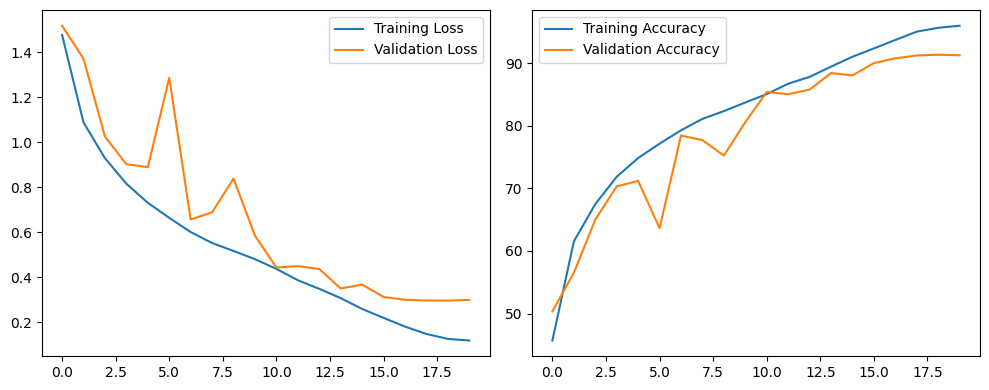

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(tracking['train_loss'], label='Training Loss')
axes[0].plot(tracking['val_loss'], label='Validation Loss')

axes[1].plot(tracking['train_acc'], label='Training Accuracy')
axes[1].plot(tracking['val_acc'], label='Validation Accuracy')

axes[0].legend()
axes[1].legend()

plt.tight_layout()
plt.show()

In [21]:
print('- Classification Report -')

classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

print(classification_report(actuals, preds, target_names=classes))

- Classification Report -
              precision    recall  f1-score   support

    airplane       0.89      0.90      0.89      1000
  automobile       0.98      0.90      0.94      1000
        bird       0.90      0.78      0.84      1000
         cat       0.70      0.85      0.77      1000
        deer       0.81      0.94      0.87      1000
         dog       0.88      0.78      0.83      1000
        frog       0.96      0.85      0.90      1000
       horse       0.96      0.88      0.92      1000
        ship       0.91      0.96      0.93      1000
       truck       0.88      0.96      0.92      1000

    accuracy                           0.88     10000
   macro avg       0.89      0.88      0.88     10000
weighted avg       0.89      0.88      0.88     10000



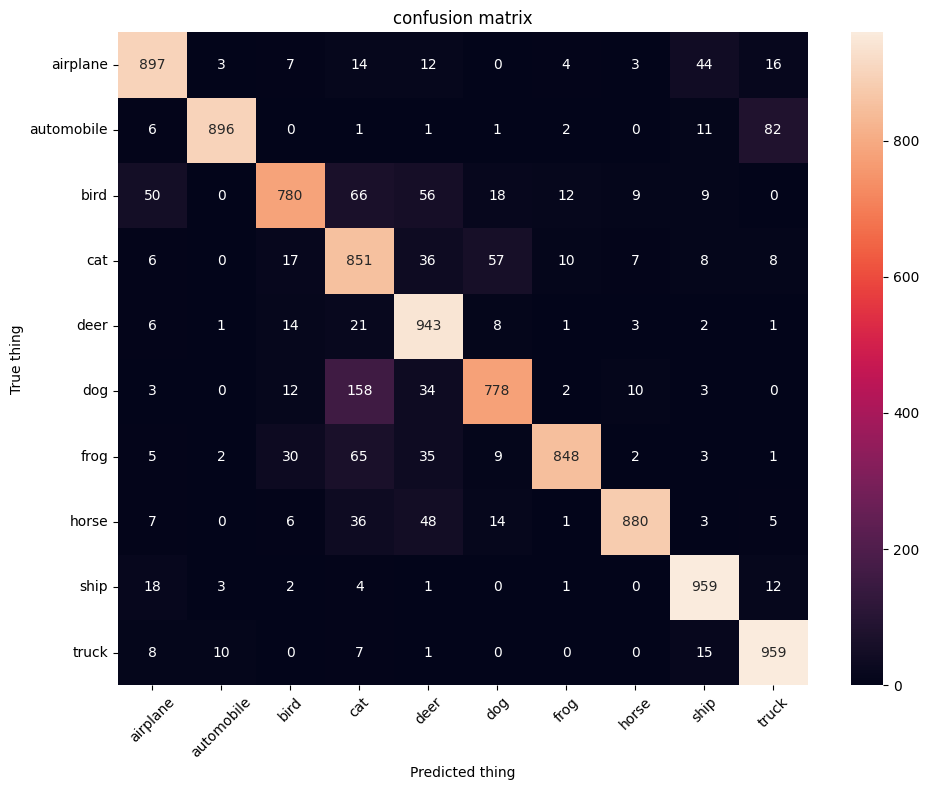

In [22]:
cm = confusion_matrix(actuals, preds)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d',
    xticklabels=classes,
    yticklabels=classes
)

plt.title('confusion matrix')
plt.xlabel('Predicted thing')
plt.ylabel('True thing')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()